In [3]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [4]:
PROJECT_DIR = Path(os.environ['PROJECT_DIR'])
PREPROCESSED_DATA_PATH = PROJECT_DIR / 'data/preprocessed_data'

In [5]:
df = pd.read_csv(PREPROCESSED_DATA_PATH / 'data.csv')
split_df = pd.read_csv(PREPROCESSED_DATA_PATH / 'split.csv').set_index('participant_id')
df['split'] = df['participant_id'].apply(lambda i: split_df.loc[i]['split'])

In [6]:
train_df = df[df['split'] == 'train']
test_df = df[df['split'] == 'test']

In [7]:
y_train = train_df['phq_binary'].to_numpy().astype(int)
y_test = test_df['phq_binary'].to_numpy().astype(int)

In [9]:
import pickle

with open('train-features-1.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('test-features-1.pkl', 'rb') as f:
    X_test = pickle.load(f)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

def is_significant(p_value):
    if p_value < 0.05:
        return True
    return False

standardized_df = X_train.copy()
# Standardize the features
feature_cols = [col for col in X_train.columns if col != "phq_binary"]
standardized_df[feature_cols] = (X_train[feature_cols] - X_train[feature_cols].mean()) / X_train[feature_cols].std()
standardized_df['phq_binary'] = train_df['phq_binary'] 

In [12]:
selected_features = []
for i, feature in enumerate(feature_cols):   
    t_stat, p_val = ttest_ind(
        standardized_df[standardized_df['phq_binary'] == 0][feature], 
        standardized_df[standardized_df['phq_binary'] == 1][feature], 
        nan_policy='omit'
    )
    if is_significant(p_val):
        selected_features.append(feature)
selected_features

['tempo_spectral_features_2',
 'tempo_spectral_features_4',
 'formant_features_0',
 'formant_features_1',
 'other_features_2',
 'other_features_3',
 'other_features_4',
 'variance',
 'std_dev',
 'slope_sign_changes',
 'mean_absolute_value',
 'logarithm_detector',
 'average_amplitude_change',
 'difference_absolute_deviation',
 'mean_logarithm_kernel',
 'simple_square_integral',
 'fourth_moment',
 'fifth_moment',
 'maximum_amplitude',
 'power_spectrum_ratio',
 'mean_power',
 'total_power',
 'hjorth_activity',
 'hjorth_mobility',
 'waveform_length',
 'jitter',
 'harmonicity']

In [15]:
X_train[selected_features]

,tempo_spectral_features_2,tempo_spectral_features_4,formant_features_0,formant_features_1,other_features_2,other_features_3,other_features_4,variance,std_dev,slope_sign_changes,...,fifth_moment,maximum_amplitude,power_spectrum_ratio,mean_power,total_power,hjorth_activity,hjorth_mobility,waveform_length,jitter,harmonicity
0,1575.556473,0.011123,0.871913,0.871913,0.013558,0.070187,11.376794,0.000207,0.014380,72003.0,...,1.366832e-10,0.127289,0.663810,0.000207,43.342049,0.000207,0.239548,340.215668,0.734081,0.000008
1,1504.867042,0.013099,0.754776,0.754776,0.018529,0.104761,19.394220,0.000259,0.016079,89130.0,...,4.213394e-11,0.180481,0.653547,0.000259,71.560631,0.000259,0.286837,665.215149,0.827921,-0.000006
2,1626.108347,0.012010,0.765493,0.765493,0.014965,0.096105,38.773546,0.000243,0.015594,144542.0,...,1.918645e-08,0.183563,0.516638,0.000243,97.660637,0.000243,0.282361,847.671692,0.889657,0.000005
3,1537.549178,0.012685,0.794946,0.794946,0.016817,0.088007,12.935726,0.000236,0.015348,61176.0,...,7.062837e-09,0.145355,0.689327,0.000236,44.098244,0.000236,0.264646,394.213013,0.818626,-0.000018
4,1621.232001,0.010954,0.730337,0.730337,0.013693,0.080460,17.314637,0.000184,0.013581,104186.0,...,2.811142e-09,0.116455,0.725891,0.000184,52.826530,0.000184,0.278245,528.657837,0.902088,-0.000003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2488,2262.634379,0.006325,0.992627,0.992627,0.008604,0.017407,94.271594,0.000073,0.008545,220755.0,...,2.060176e-09,0.120575,0.490912,0.000073,128.968964,0.000073,0.087012,572.140930,0.248914,-0.000024
2489,2271.574567,0.006080,0.986422,0.986422,0.007819,0.016584,79.297786,0.000069,0.008326,206201.5,...,-7.256086e-11,0.094147,0.570969,0.000069,117.129990,0.000069,0.092369,536.733032,0.245171,-0.000028
2490,2180.019454,0.004543,0.973091,0.973091,0.006329,0.018335,59.149744,0.000032,0.005638,115552.5,...,7.582390e-11,0.065155,0.689416,0.000032,31.739286,0.000032,0.081604,218.713470,0.273821,-0.000033
2491,2121.657512,0.006386,0.990243,0.990243,0.009041,0.019145,51.864465,0.000086,0.009253,118961.5,...,-1.294586e-08,0.165100,0.286109,0.000086,89.593857,0.000086,0.081943,341.426361,0.247418,-0.000032


In [21]:
import openai
openai.api_type = 'azure'
openai.api_base = 'https://ai-factory-gpt-128.openai.azure.com'
openai.api_version = '2023-07-01-preview'
openai.api_key = '295c968e41f14a528e7a9ac793642990'

os.environ['AZURE_OPENAI_ENDPOINT'] = 'https://ai-factory-gpt-128.openai.azure.com'
os.environ['AZURE_OPENAI_API_KEY'] = '295c968e41f14a528e7a9ac793642990'

import pandas_gpt
pandas_gpt.model = 'gpt-4'

In [38]:
def remove_correlated(df, threshold=0.9):
    # Calculate correlation matrix
    corr_matrix = df.corr()
    
    # Create a boolean mask for the upper triangle of the correlation matrix
    upper_triangle_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    
    # Find index of feature columns with correlation greater than threshold
    to_drop = [column for column in range(corr_matrix.shape[1] - 1) if any(corr_matrix.iloc[column, :-1][upper_triangle_mask[column, :-1]] > threshold)]
    
    # Drop marked features
    df_reduced = df.drop(df.columns[to_drop], axis=1)
    
    return df_reduced

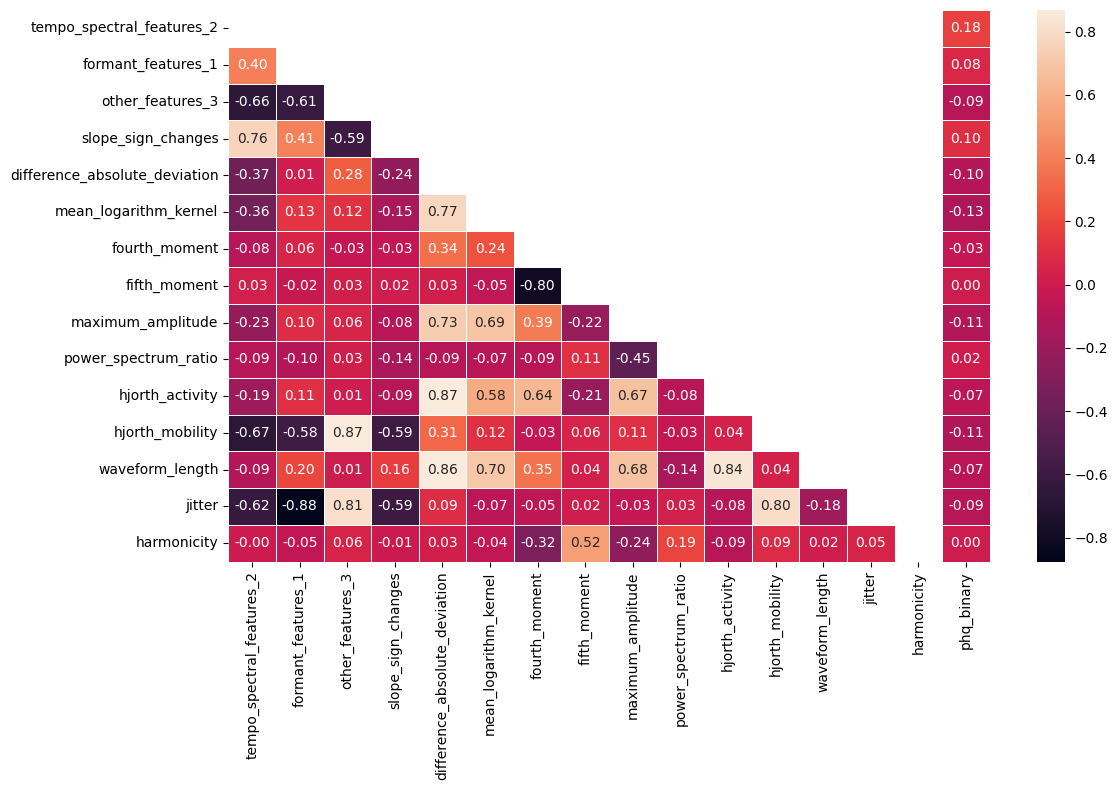

In [56]:
plt.figure(figsize=(12, 8))
corr_m = pd.concat(
    [
        remove_correlated(pd.concat([X_train[selected_features], train_df['phq_binary'].reset_index(drop=True)], axis=1)),
        train_df['phq_binary'].reset_index(drop=True)
    ], 
    axis=1
).corr()
# corr_m = pd.concat([X_train, train_df['phq_score'].reset_index(drop=True)], axis=1).corr()
up_triang = np.triu(np.ones_like(corr_m.iloc[:, :-1])).astype(bool)
up_triang[:, -1] = 0
sns.heatmap(corr_m.iloc[:-2, :-1], mask=up_triang[:-2, :], annot=True, fmt='.2f', linewidth=.5)
plt.tight_layout()